# Simple Grid World: Approximation With Linear Features

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* `gym-classics2` (see [Installation instructions](../common/Setup_gym_classics2.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

## Define A L-Maze Grid World 

In [3]:
gym_env = gym.make('LMaze-v0', tabular=False)
env = gym_env.unwrapped

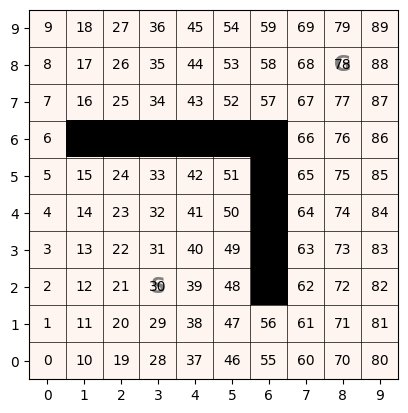

In [4]:
env.image()

In [5]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

sample_episode(env, max_len=1000)

[((3, 2), np.int64(3), 0.0, (2, 2)),
 ((2, 2), np.int64(1), 0.0, (3, 2)),
 ((3, 2), np.int64(1), 0.0, (4, 2)),
 ((4, 2), np.int64(2), 0.0, (4, 1)),
 ((4, 1), np.int64(0), 0.0, (4, 2)),
 ((4, 2), np.int64(0), 0.0, (4, 3)),
 ((4, 3), np.int64(2), 0.0, (4, 2)),
 ((4, 2), np.int64(0), 0.0, (4, 3)),
 ((4, 3), np.int64(1), 0.0, (5, 3)),
 ((5, 3), np.int64(3), 0.0, (4, 3)),
 ((4, 3), np.int64(1), 0.0, (5, 3)),
 ((5, 3), np.int64(3), 0.0, (4, 3)),
 ((4, 3), np.int64(2), 0.0, (4, 2)),
 ((4, 2), np.int64(0), 0.0, (4, 3)),
 ((4, 3), np.int64(3), 0.0, (3, 3)),
 ((3, 3), np.int64(2), 0.0, (3, 2)),
 ((3, 2), np.int64(3), 0.0, (2, 2)),
 ((2, 2), np.int64(1), 0.0, (3, 2)),
 ((3, 2), np.int64(0), 0.0, (3, 3)),
 ((3, 3), np.int64(1), 0.0, (4, 3)),
 ((4, 3), np.int64(2), 0.0, (4, 2)),
 ((4, 2), np.int64(3), 0.0, (3, 2)),
 ((3, 2), np.int64(0), 0.0, (3, 3)),
 ((3, 3), np.int64(0), 0.0, (3, 4)),
 ((3, 4), np.int64(2), 0.0, (3, 3)),
 ((3, 3), np.int64(1), 0.0, (4, 3)),
 ((4, 3), np.int64(0), 0.0, (4, 4)),
 

## Define Linear State Features

In [6]:
from gym_classics2.algorithms.linear_approximation import q_hat
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

# helper to visualize the learned policy and value function 
def plot_solution(w, title=None):
    Q = np.array([[q_hat(env.id2state(s), a, w, env) for a in env.actions()] for s in env.states()])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title, clim=(-1,1))
    
    path_non_tabular = sample_episode(env, policy=pol, max_len=100)
    path = [(env.state2id(s), a, r, env.state2id(sp)) for s, a, r, sp in path_non_tabular]
    env.image(V, policy=pol, episode=path, title='Found Path', clim=(-1,1))

Learn weights. This is a difficult problem so I use a high epsilon to increase exploration.

In [7]:
from gym_classics2.algorithms.linear_approximation import semi_gradient_Sarsa_0, state_features

# overwrite state_features for the semi-gradient Sarsa implementation in gym_classics2
def state_features(s, env):
    return np.concatenate([np.array([1]), np.array(s)])

gym_classics2.algorithms.linear_approximation.state_features = state_features


from gym_classics2.algorithms.schedules import LinearDecaySchedule

w, history = semi_gradient_Sarsa_0(env, n=200, 
                                   epsilon=LinearDecaySchedule(1, 0.001, 100), 
                                   alpha=LinearDecaySchedule(0.01, 0.001, 100),
                                   gamma=1, max_episode_length=100, verbose=False, history = True)


Semi-Gradient SARSA(0): 100%|██████████| 200/200 [00:03<00:00, 58.50it/s]


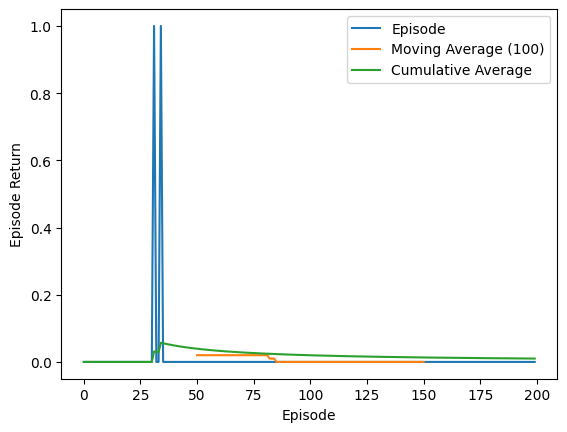

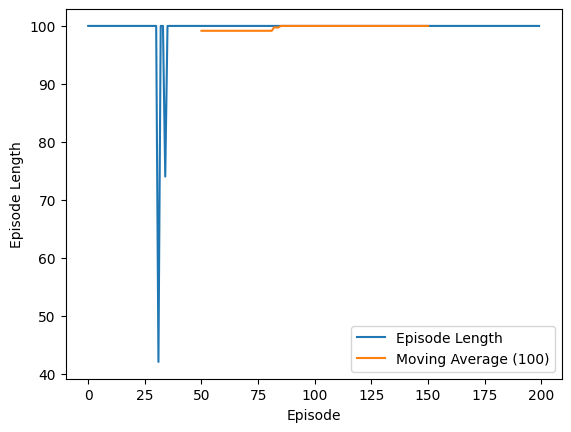

In [8]:
from gym_classics2.performance import plot_returns, plot_ep_lens
plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

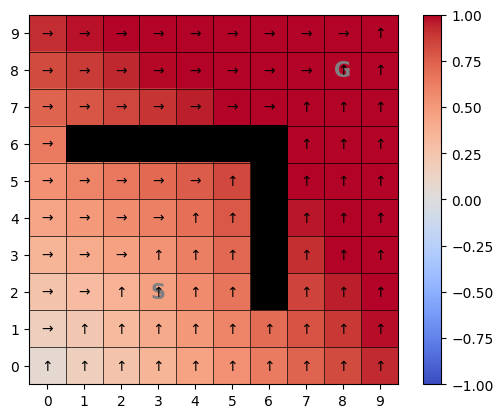

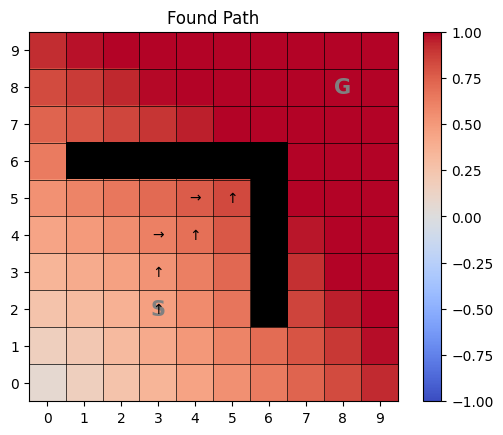

In [9]:
plot_solution(w)

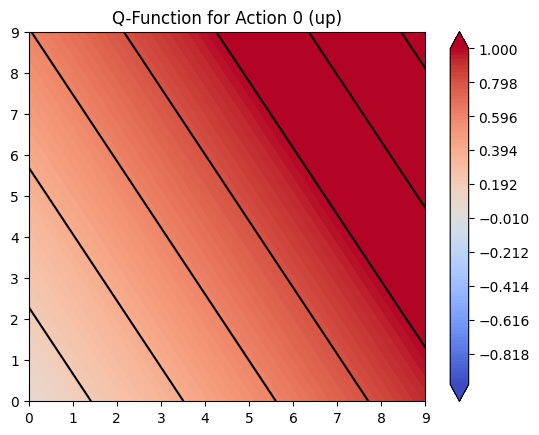

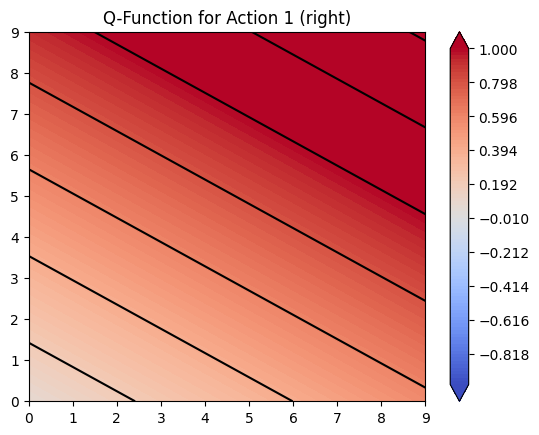

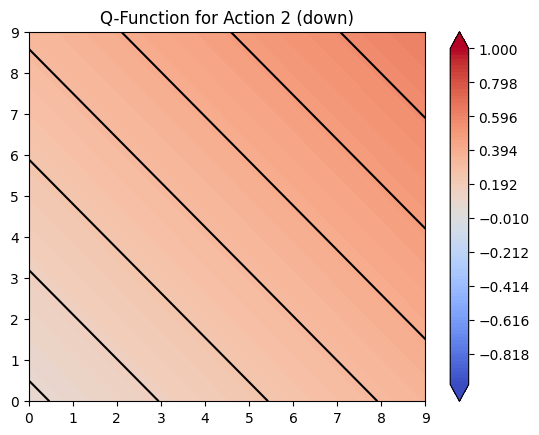

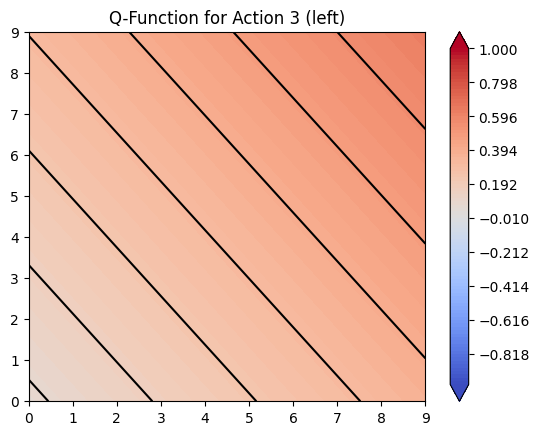

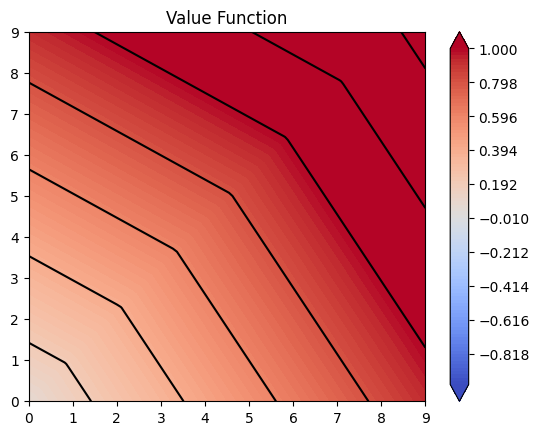

In [10]:
from matplotlib import pyplot as plt

dim = (9,9)

def active_weights(a):
    return [0] + list(range(a*2+1, a*2+2+1))

def q_hat(s, a, w): 
    # mask predictions for going outside the grid
    state = env.decode(s)
    next_state = env._next_state(state, a)[0]
    if next_state == state:
        return -100
    
    return np.dot(w[active_weights(a)], state_features(s))

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])


x = np.linspace(0, dim[0], 100)
y = np.linspace(0, dim[1], 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
    plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100), extend='both')
    plt.colorbar(extend='both')
    plt.title(f'Q-Function for Action {a} ({env.id2action(a)})')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100), extend='both')
plt.colorbar(extend='both')
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()


It is very unlikely that linear approximation works well for this problem! The agent will get stuck! We need to represent the states differently.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)